# Cancellation plus market consumption

Compare separate competing clocks with the combined death rate mu + theta q. Error bars are two analytical Monte Carlo standard errors, not simultaneous confidence intervals.

Synthetic data only. All settings and random seeds are specified below.

In [1]:
from pathlib import Path
import sys, json, platform
import numpy as np
import pandas as pd
# Embed figures in saved notebook outputs, even when MPLBACKEND=Agg.
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT / "src"))
OUT = ROOT / "results" / "synthetic" / "queues"
OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.figsize": (8, 4), "axes.grid": True, "grid.alpha": .2})
print({"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__})


{'python': '3.12.0', 'numpy': '1.26.0', 'pandas': '2.1.1'}


,mu,method,mean,theory_mean,cv,theory_cv
0,0.0,combined,25.970585,25.936888,0.246528,0.246495
1,0.0,competing,25.970585,25.936888,0.246528,0.246495
2,2.0,combined,11.775021,11.766332,0.124915,0.124702
3,2.0,competing,11.752973,11.766332,0.125772,0.124702
4,20.0,combined,3.455064,3.453267,0.102272,0.101999
5,20.0,competing,3.451822,3.453267,0.101590,0.101999
6,200.0,combined,0.476571,0.476324,0.100120,0.100038
7,200.0,competing,0.476216,0.476324,0.100981,0.100038


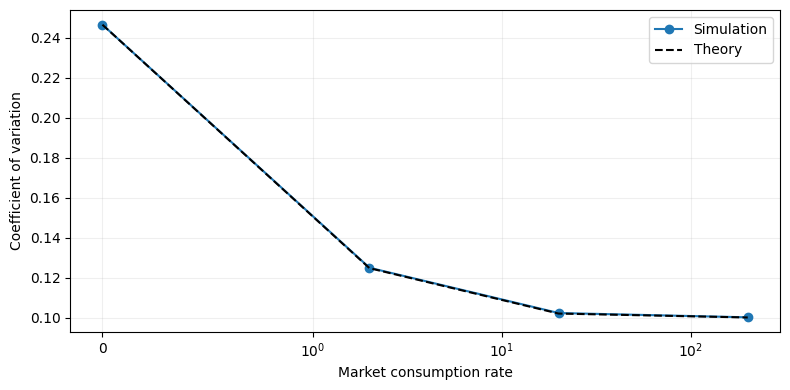

In [2]:
from queue_models.market_depletion import DepletionConfig,simulate,assess
rows=[]
for mu in (0.,2.,20.,200.):
    for method in ("combined","competing"):
        config=DepletionConfig(100,.2,mu)
        rows.append(dict(method=method,**assess(config,simulate(config,10000,seed=210,method=method))))
table=pd.DataFrame(rows);display(table[["mu","method","mean","theory_mean","cv","theory_cv"]])
table.to_csv(OUT/"market_depletion.csv",index=False)
g=table[table.method=="combined"]
plt.plot(g.mu,g.cv,"o-",label="Simulation");plt.plot(g.mu,g.theory_cv,"k--",label="Theory")
plt.xscale("symlog",linthresh=1);plt.xlabel("Market consumption rate");plt.ylabel("Coefficient of variation");plt.legend()
plt.tight_layout();plt.savefig(OUT/"market_depletion.png",dpi=140);plt.show()


## Interpretation

Compare the displayed model reference with the simulation. Finite-sample agreement is an implementation check, not evidence of real-market calibration. See [assumptions](../../../docs/model_assumptions.md) and [limitations](../../../docs/validation_and_limitations.md).